In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

import awkward as ak
import coffea
from coffea.nanoevents import NanoEventsFactory, BaseSchema, NanoAODSchema
from coffea.nanoevents.methods import candidate
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess
import coffea.util

import hist
import dask
from hist import Hist, NamedHist, loc
from hist.dask import Hist as DaskHist
import uproot

import json
import pickle
import xgboost as xgb

from helpers import *
# from plotters import *
from processors import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from coffea import processor

class DijetMaker(processor.ProcessorABC):
    def __init__(self, mode="virtual"):
        assert mode in ["eager", "virtual", "dask"]
        self._mode = mode
    
    def process(self, events):
        #dataset = events.metadata['short_name']
        events = events[events.event%20 == 0]
        muons = events.Muon
        parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
        trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]

        jets = events.Jet[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]
        trigMuons = trigMuons[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]

        try:jets = ak.with_field(jets, jets.btagRobustParTAK4B, where="btagParTB")
        except: jets = ak.with_field(jets, jets.btagUParTAK4B, where="btagParTB")
        jets = ak.with_field(jets, jets.deltaR(jets.nearest(trigMuons))<0.4, where="hasTrigMuon")

        pairs = ak.combinations(jets, 2, fields=["j1", "j2"])
        pairs = ak.drop_none(pairs[pairs.j1.hasTrigMuon | pairs.j2.hasTrigMuon])
        # pairs = ak.with_field(pairs, pairs.j1.btagParTB + pairs.j2.btagParTB, where="summedParT")
        pairs = ak.with_field(pairs, pairs.j1.btagDeepFlavB + pairs.j2.btagDeepFlavB, where="summedParT")

        best_pair = ak.drop_none(ak.firsts(pairs[ak.argmax(pairs.summedParT, axis=-1, keepdims=True)]))
        best_jet1 = best_pair.j1; best_jet2 = best_pair.j2

        #jet1_ParT = best_jet1.btagDeepFlavB; jet2_ParT = best_jet2.btagDeepFlavB
        jet1_DeepJet = best_jet1.btagDeepFlavB; jet2_DeepJet = best_jet2.btagDeepFlavB

        dijet_mass = (best_jet1 + best_jet2).mass
        dijet_pt = (best_jet1 + best_jet2).pt
        # dijet_pt_scalar = best_pair.j1.pt + best_pair.j2.pt
        
        # lower_ParT = ak.where(jet1_ParT < jet2_ParT, jet1_ParT, jet2_ParT)  
        lower_DeepJet = ak.where(jet1_DeepJet < jet2_DeepJet, jet1_DeepJet, jet2_DeepJet)  
        
        dijet_4d_hist = (
            Hist.new
            .Reg(150, 40, 340, name="a", label="$m_{jj}$ [GeV]")
            .Reg(50, 0, 250, name="b", label="$p_T^{jj}$ [GeV]")  # .Reg(50, 0, 250, name="c", label="$p_T^{jj, scalar}$ [GeV]")
            .Reg(50, 0.0, 1, name="d", label="DeepJet $b$-tag score (lower)")
            #.Reg(100, 0.0, 1, name="e", label="ParT $b$-tag score (lower)")
            .Double()
        )
        
        dijet_4d_hist.fill(
            a=dijet_mass,
            b=dijet_pt, # c=dijet_pt_scalar_flat,
            d=lower_DeepJet #e=lower_ParT
        )
        
        return {
            "entries": ak.num(events, axis=0),
            "dijet_4d": dijet_4d_hist
        }
    def postprocess(self, accumulator):
        pass

In [3]:
# uproot style running for testing
input_name = "SingleMuon24B_0_4"
json_name = f"filesets/{input_name}_replicas_info.json"
with open(json_name, "rt") as file:
    part_fileset = json.load(file)

filename = f"preprocs/{input_name}_preprocessed.coffea"
if os.path.exists(filename):
    print(f"Loading preprocessed from {filename}...")
    with open(filename, "rb") as f:
        preprocessed_available = pickle.load(f)
else:
    print("Preprocessing...")
    preprocessed_available, preprocessed_total = preprocess(
            part_fileset,
            step_size=100_000,
            align_clusters=None,
            skip_bad_files=True,
            recalculate_steps=False,
            files_per_batch=1,
            file_exceptions=(OSError,),
            save_form=True,
            uproot_options={},
            step_size_safety_factor=0.5,
        )
    
    print(f"Saved to {filename}")

    with open(filename, "wb") as f:
        pickle.dump(preprocessed_available, f)

# run on preprocessed data
# tg, rep = apply_to_fileset(
#     # data_manipulation=DijetBDT(model_path="models/bdt_model.json", metadata_path="models/bdt_model_metadata.pkl"),
#     data_manipulation=DijetBDT(model_path="models/bdt_model.json", metadata_path="models/bdt_model_metadata.pkl"),
#     fileset=preprocessed_available,
#     schemaclass=NanoAODSchema,
#     uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
# )
# out, rep = dask.compute(tg, rep)
# print(out)
# dataset_name = 'SingleMuParking_2024_EraI'
# hist_4d = out[dataset_name]['dijet_4d']

# coffea.util.save(out, f"2024_I_part.coffea")

Loading preprocessed from preprocs/SingleMuon24B_0_4_preprocessed.coffea...


In [3]:
# distributed running
import time
from datetime import datetime
from distributed import Client
from lpcjobqueue import LPCCondorCluster
from coffea.processor import SimpleCheckpointer

cluster = LPCCondorCluster(ship_env=True, log_directory="/uscms/home/ccosby/logs")
cluster.adapt(minimum=1, maximum=100)
client = Client(cluster)

# set up checkpoints
datestring = datetime.now().strftime('%Y%m%d%H')
checkpointer = SimpleCheckpointer(checkpoint_dir=f'checkpoints/{datestring}', verbose=True)

client
cluster

Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://131.225.188.227:10020,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [65]:
#close client and cluster
client.close()
cluster.close() 

In [6]:
# set up runner
client.wait_for_workers(1)
runner = processor.Runner(
     #executor = processor.FuturesExecutor(),
     executor = processor.DaskExecutor(client=client),
     savemetrics=True,
     schema=NanoAODSchema,
     # maxchunks=1, # for testing
     chunksize=100000,
     skipbadfiles=True,
     align_clusters=False,
     # checkpointer = checkpointer
)
from coffea.processor.executor import FileMeta

#output = runner.run('preproc_SingleMuon24_available.json', processor_instance=DijetMaker())
output, metrics = runner('SingleMuon24_replicas_info.json', processor_instance=DijetMaker())

/usr/local/lib/python3.10/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 20.98 
MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119322/119322 [ 1:53:04 < 0:00:00 | ? chunk/s ]

In [2]:
fn = "9bc5764d-1d22-41d1-ac50-52a16aab6242.root:Events"
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='eager').events()
# eventsE = NanoEventsFactory.from_root("root://cmseos.fnal.gov//eos/uscms/store/data/Run2024E/ParkingSingleMuon4/NANOAOD/PromptReco-v2/000/381/516/00000/734b3031-8bd9-426f-9478-55138c5b7a45.root:Events", schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='eager').events()

In [3]:
events.Jet.fields


['chMultiplicity',
 'jetId',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagRobustParTAK4B',
 'btagRobustParTAK4CvB',
 'btagRobustParTAK4CvL',
 'btagRobustParTAK4QG',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsigmaPhiPhi',
 'mass',
 'muEF',
 'muonSubtrFactor',
 'neEmEF',
 'neHEF',
 'phi',
 'pt',
 'rawFactor',
 'electronIdx1G',
 'electronIdx2G',
 'muonIdx1G',
 'muonIdx2G',
 'muonIdxG',
 'electronIdxG']

In [122]:
# TESTING
#  events = events[events.event%20 == 0]
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='eager').events()

muons = events.Muon
parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]

jets = events.Jet[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]
trigMuons = trigMuons[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]

try:jets = ak.with_field(jets, jets.btagRobustParTAK4B, where="btagParTB")
except: jets = ak.with_field(jets, jets.btagUParTAK4B, where="btagParTB")
jets = ak.with_field(jets, jets.deltaR(jets.nearest(trigMuons))<0.4, where="hasTrigMuon")

pairs = ak.combinations(jets, 2, fields=["j1", "j2"])
pairs = ak.drop_none(pairs[pairs.j1.hasTrigMuon | pairs.j2.hasTrigMuon])
pairs = ak.with_field(pairs, pairs.j1.btagParTB + pairs.j2.btagParTB, where="summedParT")

best_pair = ak.drop_none(ak.firsts(pairs[ak.argmax(pairs.summedParT, axis=-1, keepdims=True)]))
best_jet1 = best_pair.j1; best_jet2 = best_pair.j2

jet1_ParT = best_jet1.btagParTB; jet2_ParT = best_jet2.btagParTB
jet1_DeepJet = best_jet1.btagDeepFlavB; jet2_DeepJet = best_jet2.btagDeepFlavB

dijet_mass = (best_jet1 + best_jet2).mass
dijet_pt = (best_jet1 + best_jet2).pt
# dijet_pt_scalar = best_pair.j1.pt + best_pair.j2.pt

        
lower_ParT = ak.where(jet1_ParT < jet2_ParT, jet1_ParT, jet2_ParT)  
lower_DeepJet = ak.where(jet1_DeepJet < jet2_DeepJet, jet1_DeepJet, jet2_DeepJet)  

dijet_mass_flat = dijet_mass
dijet_pt_flat = dijet_pt
# dijet_pt_scalar_flat = ak.flatten(dijet_pt_scalar)
lower_DeepJet_flat = lower_DeepJet
lower_ParT_flat = lower_ParT

In [ ]:
pairs = ak.drop_none(ak.firsts(pairs[ak.argmax(pairs.summedParT, axis=-1, keepdims=True)]))
print("leading summedParT:", pairs.summedParT)
print("max summedParT:", ak.max(pairs.summedParT, axis=-1))


leading summedParT: [0.678, 1.13, 0.895, 0.0972, -2, 0.157, ..., 1.03, 1.03, 1.15, -2.91, 1.07]
max summedParT (sanity check): [0.678, None, 1.13, None, None, None, ..., None, 1.03, 1.03, 1.15, -2.91, 1.07]


In [106]:
print("summedParT:", pairs.summedParT)
print("mass:", (pairs.j1 + pairs.j2).mass)

summedParT: [[0.678], [], [1.13, 1.05, 1.01], ..., [1.15, ..., -2], [-2.91], [1.07, 1.03]]
mass: [[49.4], [], [60.5, 28.6, 58.6], ..., [79.2, ..., 82.6], [66.8], [117, 63.4]]


In [52]:
jets.btagParTB

<Array [[0.66, 0.0188], ..., [0.0754, ...]] type='1525 * var * float32[para...'>

In [7]:
histogram_filename = f"20percentHist{datestring}_DeepJet.pkl"
with open(histogram_filename, 'wb') as f:
    pickle.dump(output, f)
hist_4d = output['dijet_4d']

In [ ]:
with open('20percentHist.pkl', 'rb') as file:
        output = pickle.load(file)
hist_4d = output['dijet_4d']

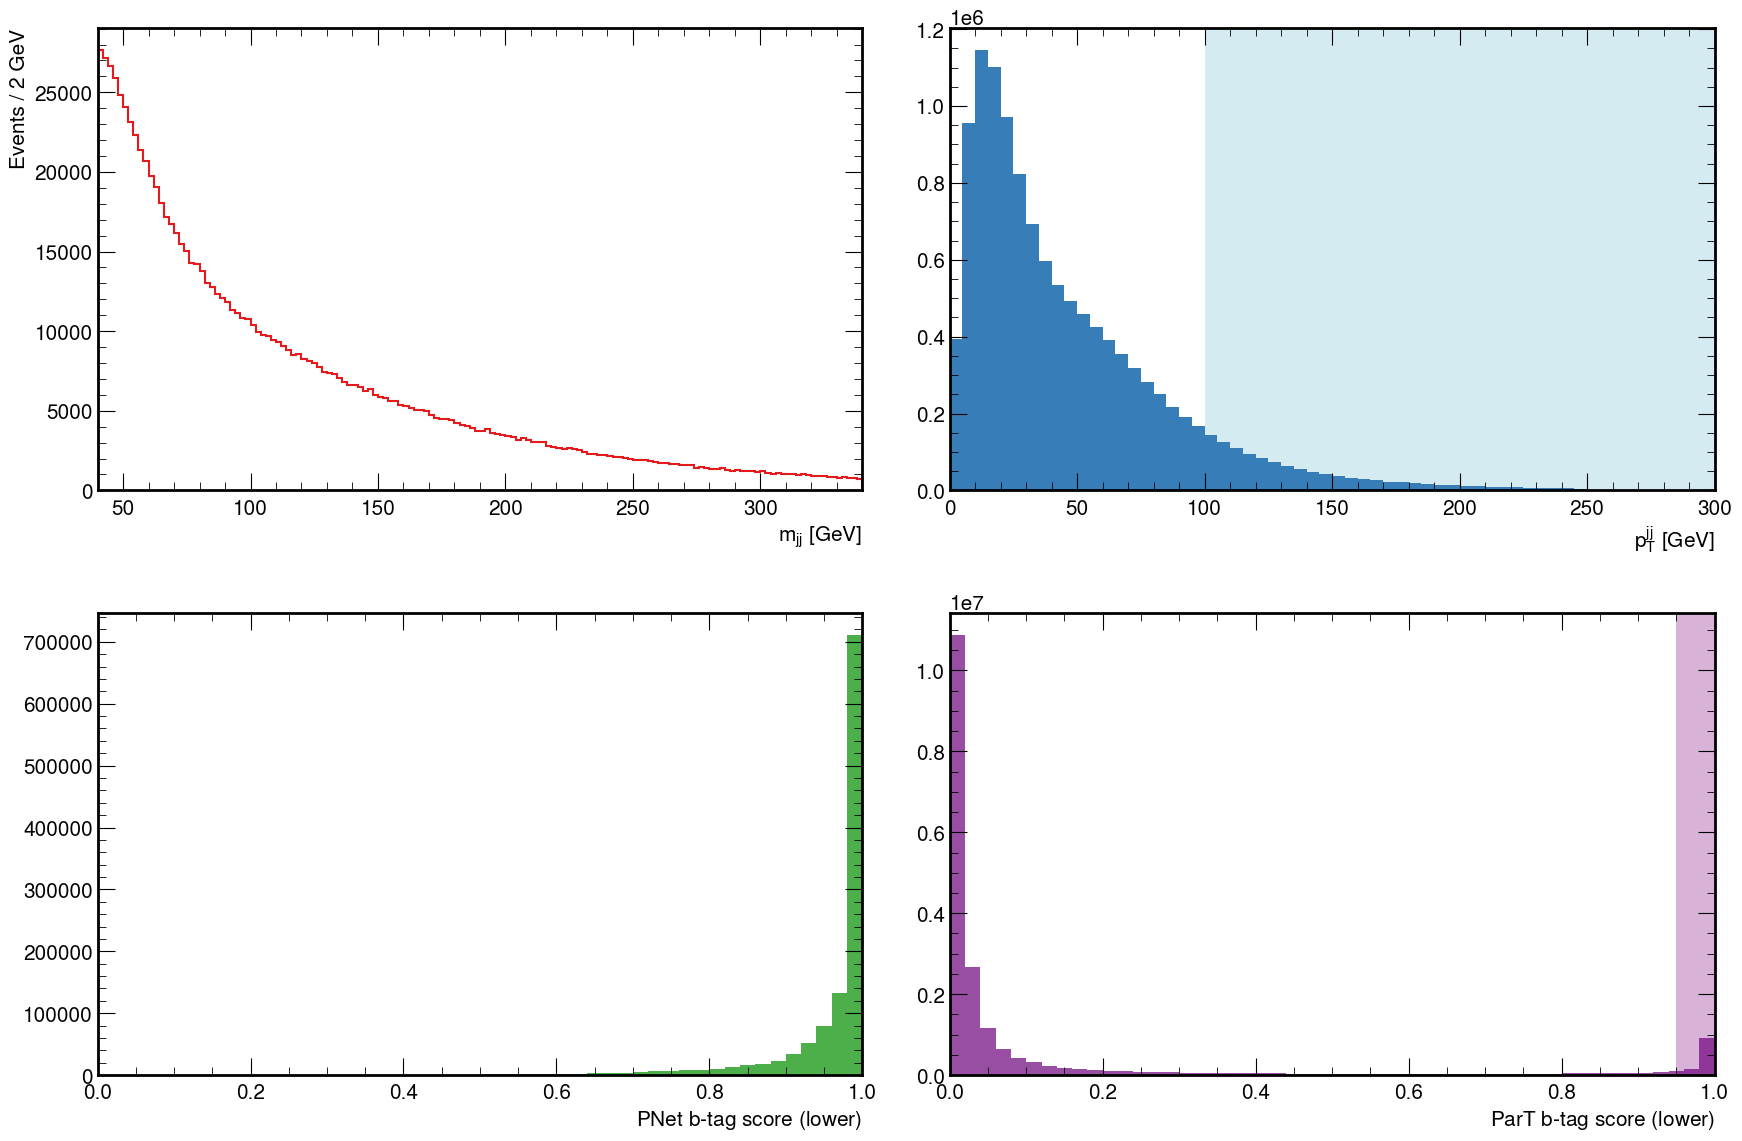

In [14]:
import mplhep
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
mplhep.style.use("CMS") 


font_size = 15
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['axes.xmargin'] = 0

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

BTag = [0.95, 1.0]
PTjj = [100, 1000]

proj_x = hist_4d[:, loc(PTjj[0]):loc(PTjj[1]):sum, sum, loc(BTag[0]):loc(BTag[1]):sum]
proj_x.plot1d(ax=axes[0, 0], label="x", color=plt.colormaps['Set1'](0), flow='none')
axes[0, 0].set_xlabel(hist_4d.axes[0].label, fontsize = font_size)
axes[0, 0].set_ylabel("Events / 2 GeV", fontsize = font_size)

proj_y = hist_4d[sum, :, sum, loc(BTag[0]):loc(BTag[1]):sum]
proj_y.plot1d(ax=axes[0, 1], fill=True, label="y", color=plt.colormaps['Set1'](1), flow='none')
axes[0, 1].set_xlim(0, 300)
axes[0, 1].set_xlabel(hist_4d.axes[1].label, fontsize=font_size)
rect = patches.Rectangle((PTjj[0], 0.0), width=PTjj[1]-PTjj[0], height=axes[0,1].get_ylim()[1], facecolor='lightblue', alpha=0.5, zorder=0)
axes[0,1].add_patch(rect)

proj_z = hist_4d[sum, loc(PTjj[0]):loc(PTjj[1]):sum,:, loc(BTag[0]):loc(BTag[1]):sum]
proj_z.plot1d(ax=axes[1, 0], fill=True, label="z", color=plt.colormaps['Set1'](2), flow='none')
axes[1, 0].set_xlabel(hist_4d.axes[2].label, fontsize=font_size)

proj_a = hist_4d[sum, loc(PTjj[0]):loc(PTjj[1]):sum, sum, :]

proj_a.plot1d(ax=axes[1, 1], fill=True, label="a", color=plt.colormaps['Set1'](3), flow='none')
rect = patches.Rectangle((BTag[0], 0.0), width=BTag[1]-BTag[0], height=axes[1,1].get_ylim()[1], facecolor='purple', alpha=0.3)
axes[1,1].add_patch(rect)

axes[1, 1].set_xlabel(hist_4d.axes[3].label, fontsize=font_size)

plt.tight_layout()
plt.show()

In [17]:
fn= "background_Sum24_1mil_QCD.root:Events"
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='virtual').events()
event=events[(events.HLT.Mu10_Barrel_L1HP11_IP6)]

jets = events.Jet    
b_jets = jets[jets.btagPNetB > BTag[0]]
pairs = ak.combinations(b_jets, 2, fields=["b1", "b2"])
dijets = pairs.b1 + pairs.b2

m_bb = ak.flatten(dijets.mass)

In [16]:
fnSig= "signal_Sum24_1mil_ggF.root:Events"
eventsSig = NanoEventsFactory.from_root(fnSig, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='virtual').events()
eventsSig=eventsSig[(eventsSig.HLT.Mu10_Barrel_L1HP11_IP6)]
jetsSig = eventsSig.Jet    
b_jetsSig = jetsSig[jetsSig.btagPNetB > BTag[0]]
pairsSig = ak.combinations(b_jetsSig, 2, fields=["b1", "b2"])
dijetsSig = pairsSig.b1 + pairsSig.b2

h_bb = ak.flatten(dijetsSig.mass)

In [ ]:
print(eventsSig.LHEWeight[0])

{originalXWGTUP: 32.6}


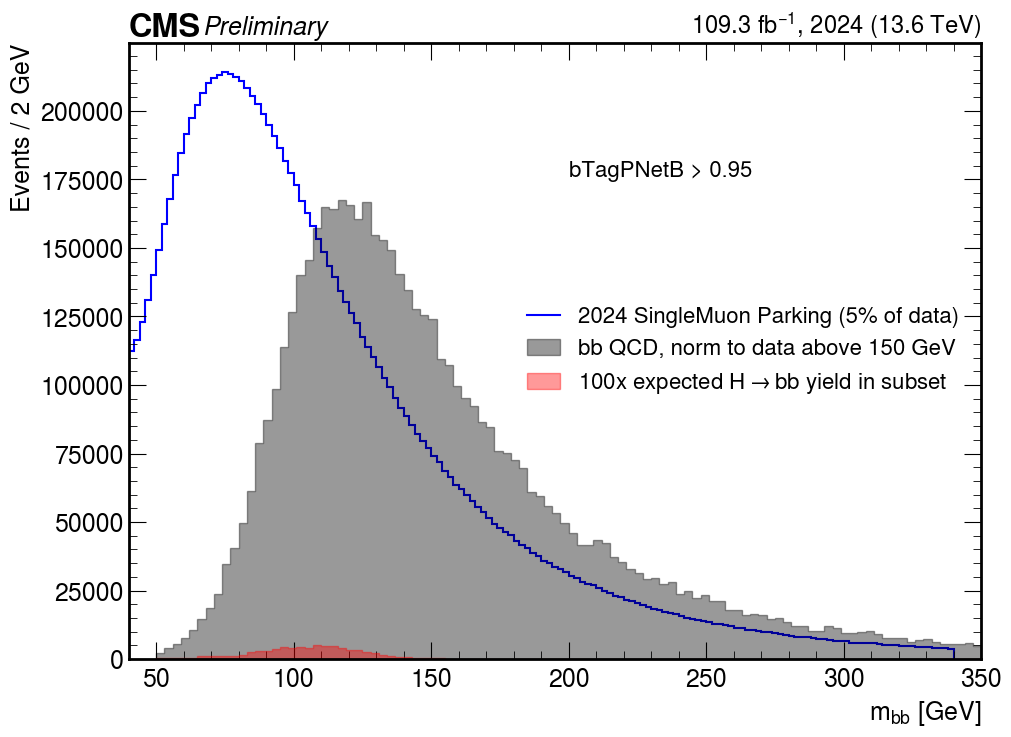

In [19]:
fig, ax = plt.subplots(figsize=(11, 8))
BTag = [0.95, 1.0]
PTjj = [0, 1000]
font_size = 18
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
proj_x = hist_4d[:, loc(PTjj[0]):loc(PTjj[1]):sum, sum, loc(BTag[0]):loc(BTag[1]):sum]
proj_x.plot1d(ax=ax, label="2024 SingleMuon Parking (5% of data)", color='blue', flow='none')
ax.set_xlabel("$m_{bb}$ [GeV]", fontsize = font_size)
ax.set_ylabel("Events / 2 GeV", fontsize = font_size)


ax.hist(ak.flatten(dijets[dijets.pt > PTjj[0]].mass), bins=100, range=(50, 350), histtype='step', fill=True, color='black', 
        alpha=0.4, weights=49*np.ones_like(ak.flatten(dijets[dijets.pt > PTjj[0]].mass)), label="bb QCD, norm to data above 150 GeV")


sigfactor = 100*(3.5/20) # expect 3.5 mil hbb produced in 24, but only 1 mil in sample; scaled down to the 20% of data shown; 100x for visibility 
ax.hist(ak.flatten(dijetsSig.mass), bins=100, range=(50, 350), histtype='step', fill=True, color='red', 
        alpha=0.4, weights=sigfactor*np.ones_like(ak.flatten(dijetsSig.mass)), label="100x expected $H \\to bb$ yield in subset")

mplhep.cms.label('Preliminary', data=True, year='2024', lumi=109.32, com=13.6, lumi_format='{0:.1f}', fontsize=18, ax=ax)
plt.text(200, 176000, 'bTagPNetB > 0.95', fontsize=16)
ax.legend(fontsize=font_size-2)
plt.show()

In [ ]:
fn_sig= "higgsToBB_v15.root:Events"
eventsSig = NanoEventsFactory.from_root(fn_sig, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='virtual').events()

fn_qcd= "QCD_lowthresh_v15.root:Events"
eventsQCD = NanoEventsFactory.from_root(fn_qcd, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='virtual').events()



In [256]:
mc_hists = {}

filenames = ["higgsToBB_v15.root:Events", "QCD_lowthresh_v15.root:Events"]


for file in filenames:
    name = file[0:3]
    events = NanoEventsFactory.from_root(file, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='virtual').events()
    for tagger in ["DeepJet", "UParT"]:
        muons = events.Muon
        parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) 
        trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]
            
        jets = events.Jet[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]
        trigMuons = trigMuons[(events.HLT.Mu10_Barrel_L1HP11_IP6) & (ak.num(trigMuons) > 0)]

        if tagger == "DeepJet":
            jets = ak.with_field(jets, jets.btagDeepFlavB, where="btag")
        elif tagger == "UParT":
            try:jets = ak.with_field(jets, jets.btagRobustParTAK4B, where="btag")
            except: jets = ak.with_field(jets, jets.btagUParTAK4B, where="btag")

        jets = ak.with_field(jets, jets.deltaR(jets.nearest(trigMuons))<0.4, where="hasTrigMuon")

        pairs = ak.combinations(jets, 2, fields=["j1", "j2"])
        pairs = ak.drop_none(pairs[pairs.j1.hasTrigMuon | pairs.j2.hasTrigMuon])
        # pairs = ak.with_field(pairs, pairs.j1.btagParTB + pairs.j2.btagParTB, where="summedParT")
        pairs = ak.with_field(pairs, pairs.j1.btag + pairs.j2.btag, where="summedParT")

        best_pair = ak.drop_none(ak.firsts(pairs[ak.argmax(pairs.summedParT, axis=-1, keepdims=True)]))
        best_jet1 = best_pair.j1; best_jet2 = best_pair.j2

        jet1_tagger = best_jet1.btag; jet2_tagger = best_jet2.btag

        dijet_mass = (best_jet1 + best_jet2).mass
        dijet_pt = (best_jet1 + best_jet2).pt
        # dijet_pt_scalar = best_pair.j1.pt + best_pair.j2.pt
                
        # lower_ParT = ak.where(jet1_ParT < jet2_ParT, jet1_ParT, jet2_ParT)  
        lower_tagger = ak.where(jet1_tagger < jet2_tagger, jet1_tagger, jet2_tagger)

        dijet_3d_hist = (
                    Hist.new
                    .Reg(50, 40, 340, name="a", label="$m_{jj}$ [GeV]")
                    .Reg(50, 0, 250, name="b", label="$p_T^{jj}$ [GeV]")  # .Reg(50, 0, 250, name="c", label="$p_T^{jj, scalar}$ [GeV]")
                    .Reg(50, 0.0, 1, name="d", label="DeepJet $b$-tag score (lower)")
                    #.Reg(100, 0.0, 1, name="e", label="ParT $b$-tag score (lower)")
                    .Double()
        )
                
        dijet_3d_hist.fill(
                    a=dijet_mass,
                    b=dijet_pt, # c=dijet_pt_scalar_flat,
                    d=lower_tagger #e=lower_ParT
        ) 
        mc_hists[f"{name}_{tagger}"] = dijet_3d_hist


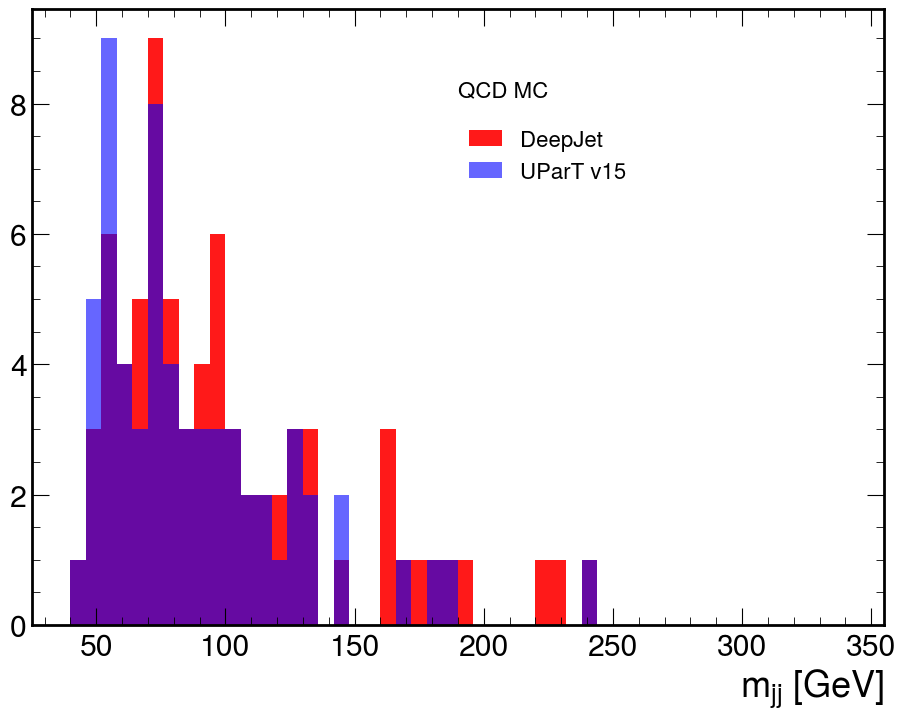

In [316]:
import mplhep
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
mplhep.style.use("CMS") 

fig, ax = plt.subplots(figsize=(11, 8))
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
BTag = [0., 1.0]
PTjj = [0, 1000]


# hig_DeepJet = mc_hists["hig_DeepJet"][:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
# hig_DeepJet.plot1d(ax=ax, label="DeepJet", alpha=0.9, color='red', flow='none', yerr=False, fill=True)

# hig_UParT = mc_hists["hig_UParT"][:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
# hig_UParT.plot1d(ax=ax, label="UParT v15", alpha=0.6, color='blue', flow='none', yerr=False, fill=True)

# print(hig_UParT.counts)
# print(40+100* np.mean(hig_UParT))
# print(40+100* np.mean(hig_DeepJet))
QCD_DeepJet = mc_hists["QCD_DeepJet"][:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
QCD_DeepJet.plot1d(ax=ax, label="DeepJet", alpha=0.9, color='red', flow='none', yerr=False, fill=True)

QCD_UParT = mc_hists["QCD_UParT"][:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
QCD_UParT.plot1d(ax=ax, label="UParT v15",  alpha=0.6, color='blue', flow='none', yerr=False, fill=True)
ax.text(0.5, 0.85, f'QCD MC', horizontalalignment='left', verticalalignment='bottom', transform=ax.transAxes, fontsize=16)
ax.legend(fontsize=font_size-2, loc=(0.5, 0.7))

plt.show()

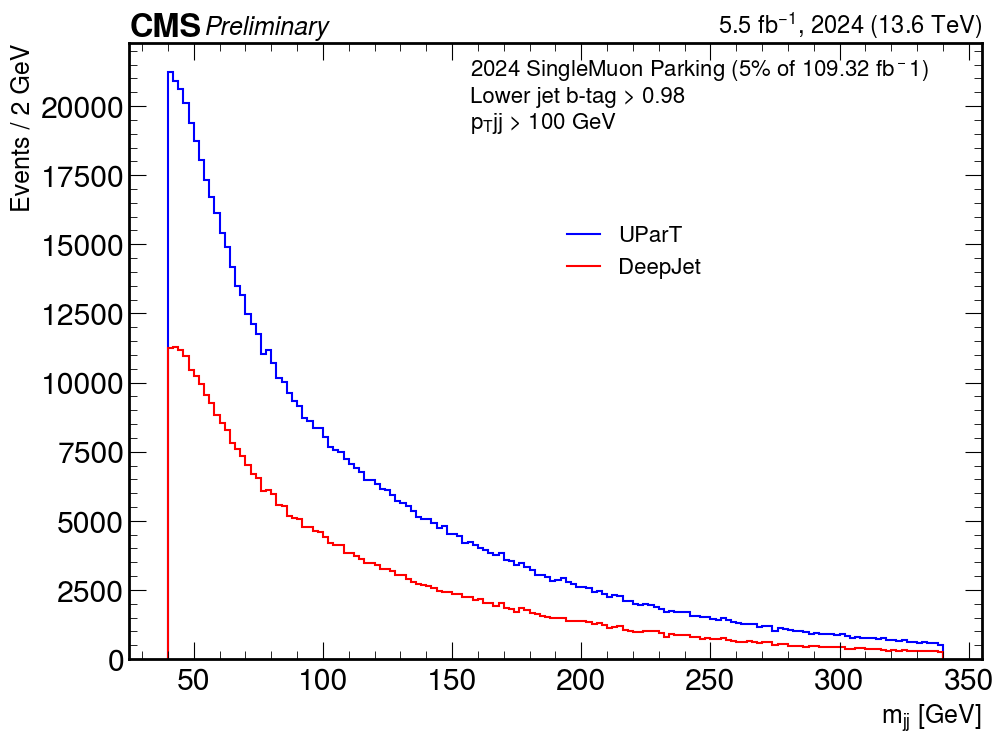

In [287]:
import mplhep
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
mplhep.style.use("CMS") 


with open('20percentHist2026021612_UParT.pkl', 'rb') as file:
        ParT = pickle.load(file)
hist_part = ParT['dijet_4d']

with open('20percentHist2026021618_DeepJet.pkl', 'rb') as file:
        DeepJet = pickle.load(file)
hist_DeepJet = DeepJet['dijet_4d']

fig, ax = plt.subplots(figsize=(11, 8))
BTag = [0.98, 1.0]
PTjj = [100, 1000]
font_size = 18
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
mjj_ParT = hist_part[:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
mjj_ParT.plot1d(ax=ax, label="UParT", color='blue', flow='none')
mjj_DeepJet = hist_DeepJet[:, loc(PTjj[0]):loc(PTjj[1]):sum, loc(BTag[0]):loc(BTag[1]):sum]
mjj_DeepJet.plot1d(ax=ax, label="DeepJet", color='red', flow='none')

ax.set_xlabel("$m_{jj}$ [GeV]", fontsize = font_size)
ax.set_ylabel("Events / 2 GeV", fontsize = font_size)


mplhep.cms.label('Preliminary', data=True, year='2024', lumi=0.05*109.32, com=13.6, lumi_format='{0:.1f}', fontsize=18, ax=ax)
ax.text(0.4, 0.85, f'2024 SingleMuon Parking (5% of 109.32 fb$^{-1}$)\nLower jet b-tag > {BTag[0]}\n$p_Tjj$ > {PTjj[0]} GeV',
        horizontalalignment='left', verticalalignment='bottom', transform=ax.transAxes, fontsize=16)
ax.legend(fontsize=font_size-2, loc=(0.5, 0.6))
plt.show()

In [ ]:
print(ak.count(m_bb[m_bb > 150])*49)
print(hist_4d[loc(150)::sum, loc(PTjj[0]):loc(PTjj[1]):sum, sum, loc(BTag[0]):loc(BTag[1]):sum])
print(ak.count(h_bb)*sigfactor)


In [ ]:
# #simple plotting loop
# # Create the sliced histogram ONCE before the loop
# # Adjust the slice range as needed (e.g., np.s_[1j] for bin 1, or slice(0.0j, None) for all bins >= 0)
# sliced = hist_4d[{"a": np.s_[1j]}]  # Change "a" to the axis you want to slice on, and adjust the slice range

# for i, axis in enumerate(hist_4d.axes):
#     fig, ax = plt.subplots(figsize=(10, 6)) 
#     # ax.set_yscale('log')
#     # Project each axis from the sliced histogram
#     sliced.project(axis.name).plot1d(ax=ax, fill=True, label=axis.name, color=plt.colormaps['Set1'](i), flow='none')
#     plt.show()

In [ ]:
# set up runner
# client.wait_for_workers(1)
runner = processor.Runner(
     executor = processor.FuturesExecutor(),
     # executor = processor.DaskExecutor(client=client),
     savemetrics=True,
     schema=NanoAODSchema,
    #  maxchunks=1, # for testing
     chunksize=100,
     skipbadfiles=True,
     align_clusters=False,
     # checkpointer = checkpointer
)
import uuid
from coffea.processor.executor import FileMeta

# def unfuck_uuid(item: str) -> bytes:
#     return uuid.UUID(hex=item.replace('-', '')).bytes

# def gen_from_json(filename):
#     with open(filename) as fin:
#         stuff = json.load(fin)

#     for dataset, info in stuff.items():
#         for filename, fileinfo in info["files"].items():
#             user_meta = {
#                 "dataset": dataset,
#                 "uuid": unfuck_uuid(fileinfo["uuid"]),
#                 "numentries": fileinfo["num_entries"],
#             }
#             yield FileMeta(dataset, filename, fileinfo["object_path"], user_meta)


# gen = runner._normalize_fileset("SingleMuon24B_0_4_replicas_info.json", "Events")
# gen = runner._chunk_generator(preprocessed_available, "Events")
# gen = runner._chunk_generator(runner._normalize_fileset("preproc_SingleMuon24_available_part.json", "Events"), "Events")
# gen = runner._chunk_generator(gen_from_json("preproc_SingleMuon24_part_available.json"), "Events")

# for i in gen:
#     print(i.metadata)
# from coffea.processor.executor import FileMeta


# go
#output = runner.run('preproc_SingleMuon24_available.json', processor_instance=DijetMaker())
output, metrics = runner('SingleMuon24_replicas_info.json', processor_instance=DijetMaker())